Accuracy: 0.985
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       144
           1       1.00      0.95      0.97        56

    accuracy                           0.98       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.98      0.98       200



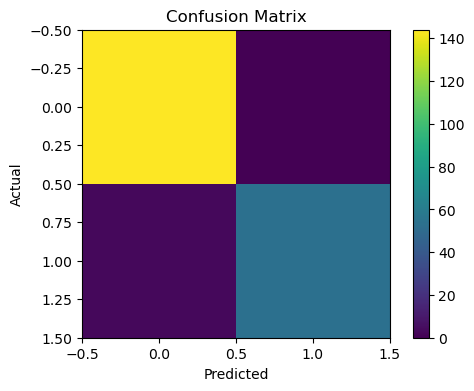

            feature  importance
5    debt_to_income    0.487774
3      credit_score    0.444010
1            income    0.023371
2       loan_amount    0.019147
0               age    0.013189
4  employment_years    0.012510


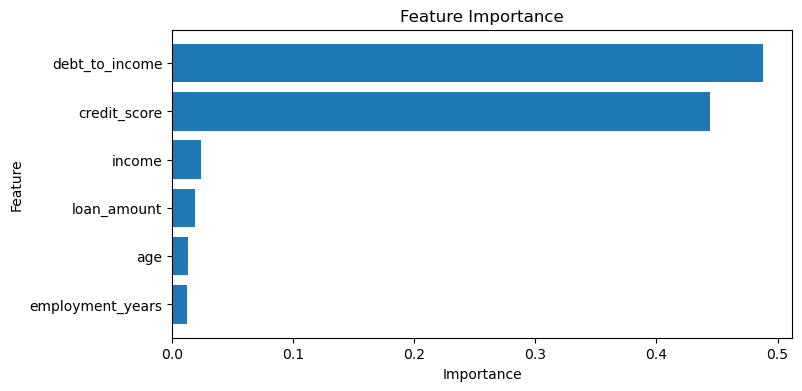

,age,income,loan_amount,credit_score,employment_years,debt_to_income,actual_default,predicted_default,default_probability,risk_level
521,47,111121,62804,628,24,0.651378,0,0,0.00,Low Risk
737,37,109148,67424,700,24,0.313807,0,0,0.00,Low Risk
740,40,100316,85797,555,21,0.395070,0,0,0.04,Low Risk
660,65,41536,55288,630,2,0.624177,0,0,0.04,Low Risk
411,66,178922,47533,487,25,0.434012,1,1,0.75,High Risk
678,48,36154,35254,424,22,0.690501,1,1,0.98,High Risk
626,55,164165,16005,659,1,0.335445,0,0,0.00,Low Risk
513,24,55931,29858,535,5,0.251055,0,0,0.02,Low Risk
859,22,62556,15800,843,34,0.194056,0,0,0.01,Low Risk
136,23,105683,23073,766,27,0.143247,0,0,0.01,Low Risk


In [1]:
# Credit Risk Prediction Project

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 2. Create synthetic customer data
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "age": np.random.randint(21, 70, n),
    "income": np.random.randint(30000, 180000, n),
    "loan_amount": np.random.randint(5000, 120000, n),
    "credit_score": np.random.randint(300, 850, n),
    "employment_years": np.random.randint(0, 35, n),
    "debt_to_income": np.random.uniform(0.05, 0.75, n)
})

# 3. Create target variable: default
data["default"] = (
    (data["debt_to_income"] > 0.4) &
    (data["credit_score"] < 600)
).astype(int)

# 4. Create features and target
X = data.drop("default", axis=1)
y = data["default"]

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 7. Predictions
y_pred = model.predict(X_test)

# 8. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# 10. Feature Importance
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

# 11. Risk Probability
y_prob = model.predict_proba(X_test)[:, 1]

# 12. Risk Segmentation
def risk_level(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_labels = [risk_level(p) for p in y_prob]

results = X_test.copy()
results["actual_default"] = y_test
results["predicted_default"] = y_pred
results["default_probability"] = y_prob
results["risk_level"] = risk_labels

results.head(10)